In [1]:
## IMPORTS AND DATA LOADING ##

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Now we can load in our cleaned data
import numpy as np 
import pandas as pd
df = pd.read_csv("/Users/stephenwillis/Desktop/archive/cleaned_loan_data_dev.csv") ## UPDATE WITH YOUR PATH
df.head()

,Id,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,FranchiseCode,UrbanRural,RevLineCr,LowDoc,Defaulted,GrAppv,SBA_Appv,ExistingBusiness
0,5767963003,OHIOPYLE,PA,15470,BNY MELLON NATL ASSOC,PA,313311,1993-07-09,1993,75,45,1,0,0.0,0.0,0.0,67000.0,56950.0,1.0
1,7554323005,ENGLEWOOD,CO,80111,WELLS FARGO BANK NATL ASSOC,CO,0,1994-09-07,1994,84,23,1,0,0.0,1.0,0.0,50000.0,45000.0,1.0
2,1999655008,SELKIRK,NY,12158,FIRST NIAGARA BANK NATL ASSOC,NY,339932,2006-09-01,2006,84,7,0,2,0.0,0.0,0.0,65000.0,32500.0,1.0
3,7897023000,NEW YORK,NY,10012,EMPIRE ST. CERT. DEVEL CORP,NY,0,1994-12-12,1995,240,50,1,0,0.0,0.0,0.0,209000.0,209000.0,1.0
4,3381625007,Central point,OR,97502,PEOPLE'S BANK OF COMMERCE,OR,236118,2009-04-16,2009,12,2,0,2,1.0,NaN,0.0,20000.0,17000.0,1.0


In [2]:
## HIGH-LEVEL OVERVIEW OF THE DATASET ##

# Basic schema, dtypes, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 807450 entries, 0 to 807449
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                807450 non-null  int64  
 1   City              807421 non-null  object 
 2   State             807440 non-null  object 
 3   Zip               807450 non-null  int64  
 4   Bank              806099 non-null  object 
 5   BankState         806092 non-null  object 
 6   NAICS             807450 non-null  int64  
 7   ApprovalDate      807450 non-null  object 
 8   ApprovalFY        807450 non-null  int64  
 9   Term              807450 non-null  int64  
 10  NoEmp             807450 non-null  int64  
 11  FranchiseCode     807450 non-null  int64  
 12  UrbanRural        807450 non-null  int64  
 13  RevLineCr         557972 non-null  float64
 14  LowDoc            802041 non-null  float64
 15  Defaulted         807450 non-null  float64
 16  GrAppv            80

In [3]:
# Summary statistics for numeric columns (count, mean, std, min, quantiles, max)
df.describe()

,Id,Zip,NAICS,ApprovalFY,Term,NoEmp,FranchiseCode,UrbanRural,RevLineCr,LowDoc,Defaulted,GrAppv,SBA_Appv,ExistingBusiness
count,8.074500e+05,807450.000000,807450.000000,807450.000000,807450.000000,807450.000000,807450.000000,807450.000000,557972.000000,802041.000000,807450.000000,8.074500e+05,8.074500e+05,807336.000000
mean,4.774615e+09,53861.228931,398605.883102,2001.136961,110.850054,11.402608,2763.723957,0.756755,0.323332,0.123585,0.175617,1.930581e+05,1.498072e+05,0.717204
std,2.536773e+09,31170.634224,263342.506312,5.914190,78.895207,72.917636,12784.752049,0.646352,0.467749,0.329107,0.380494,2.831037e+05,2.283536e+05,0.450358
min,1.000014e+09,0.000000,0.000000,1966.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+03,5.000000e+02,0.000000
25%,2.593605e+09,27610.000000,235210.000000,1997.000000,60.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.500000e+04,2.125000e+04,0.000000
50%,4.363719e+09,55416.000000,445310.000000,2002.000000,84.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,9.000000e+04,6.222000e+04,1.000000
75%,6.905982e+09,83706.000000,561730.000000,2006.000000,120.000000,10.000000,1.000000,1.000000,1.000000,0.000000,0.000000,2.250000e+05,1.750000e+05,1.000000
max,9.996003e+09,99999.000000,928120.000000,2014.000000,569.000000,9999.000000,99999.000000,2.000000,1.000000,1.000000,1.000000,5.000000e+06,5.000000e+06,1.000000


In [4]:
# Count missing values per column
df.isna().sum()

Id                       0
City                    29
State                   10
Zip                      0
Bank                  1351
BankState             1358
NAICS                    0
ApprovalDate             0
ApprovalFY               0
Term                     0
NoEmp                    0
FranchiseCode            0
UrbanRural               0
RevLineCr           249478
LowDoc                5409
Defaulted                0
GrAppv                   0
SBA_Appv                 0
ExistingBusiness       114
dtype: int64

In [5]:
# Number of unique values per column, sorted from low to high cardinality
nunique = df.nunique().sort_values()
nunique

ExistingBusiness         2
Defaulted                2
LowDoc                   2
RevLineCr                2
UrbanRural               3
ApprovalFY              48
State                   51
BankState               56
Term                   407
NoEmp                  582
NAICS                 1310
FranchiseCode         2678
Bank                  5685
ApprovalDate          9747
GrAppv               20682
City                 31223
Zip                  32711
SBA_Appv             35877
Id                  807450
dtype: int64

In [6]:
##----------------- DATA VISUALIZATION -----------------##

Defaulted value counts:
Defaulted
0.0    665648
1.0    141802
Name: count, dtype: int64

Defaulted percentages:
Defaulted
0.0    0.824
1.0    0.176
Name: count, dtype: float64


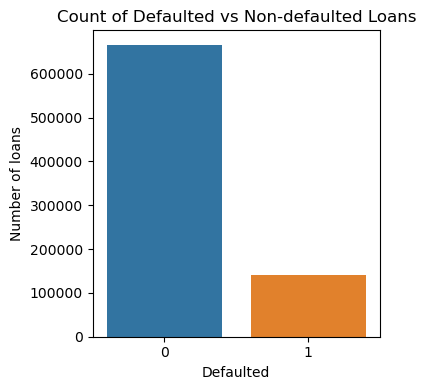

In [7]:
## TARGET DISTRIBUTION: DEFAULTED ##

# Inspect the class balance for the target variable
target_counts = df["Defaulted"].value_counts().sort_index()
target_pct = (target_counts / target_counts.sum()).round(3)

print("Defaulted value counts:")
print(target_counts)
print("\nDefaulted percentages:")
print(target_pct)

# Bar plot of class counts
plt.figure(figsize=(4, 4))
sns.barplot(x=target_counts.index.astype(int), y=target_counts.values)
plt.title("Count of Defaulted vs Non-defaulted Loans")
plt.xlabel("Defaulted")
plt.ylabel("Number of loans")
plt.tight_layout()
plt.show()


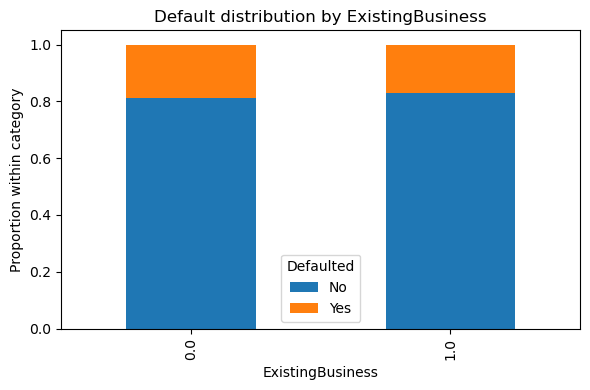

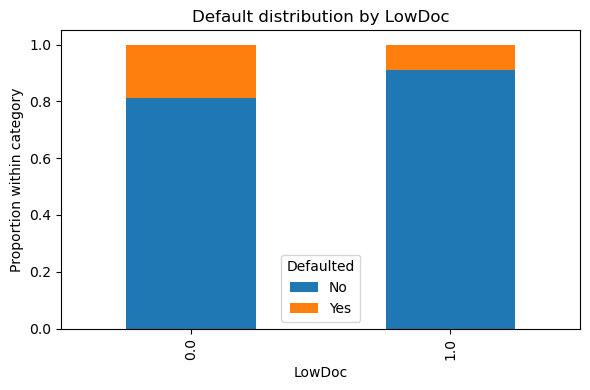

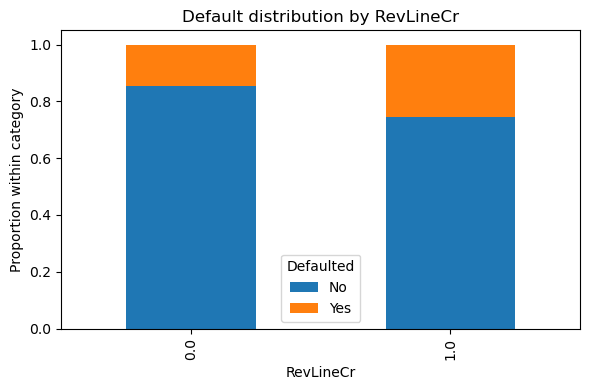

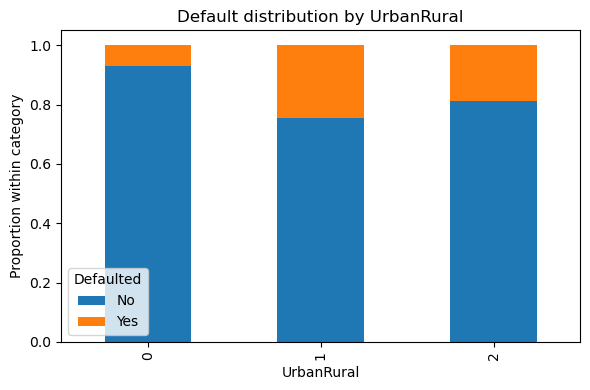

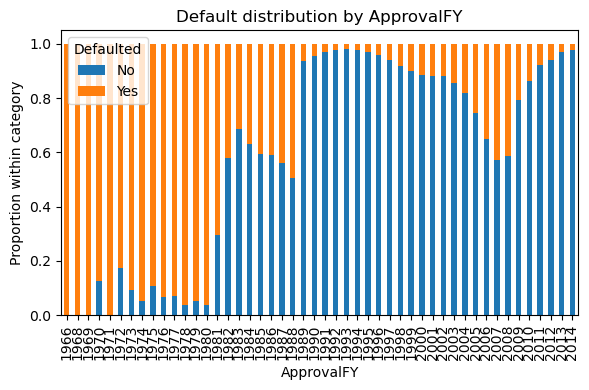

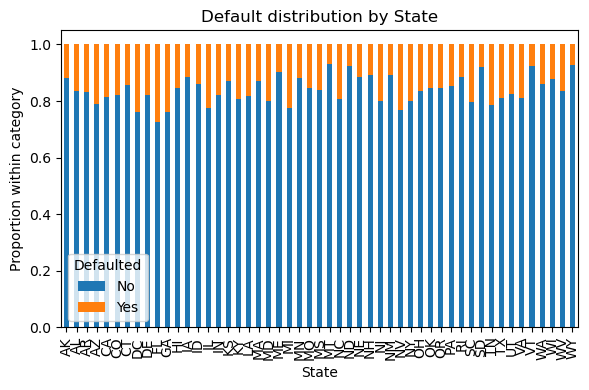

In [8]:
## LOW-CARDINALITY CATEGORICAL COLUMNS VS DEFAULTED ##

# We look at columns with the fewest distinct values.
# These are usually good candidates for visualizing default rates by category.

n = 7  # number of lowest-cardinality columns to inspect
low_cardinality_cols = nunique[:n].drop("Defaulted").index.tolist()

# For each low-cardinality column, compute the conditional proportion of Defaulted
# and plot it as a stacked bar chart.

for col in low_cardinality_cols:
    crosstab = pd.crosstab(
        index=df[col],
        columns=df["Defaulted"],
        normalize="index"  # each row sums to 1
    )

    ax = crosstab.plot(kind="bar", figsize=(6, 4), stacked=True)
    plt.title(f"Default distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion within category")
    plt.legend(title="Defaulted", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

    
    

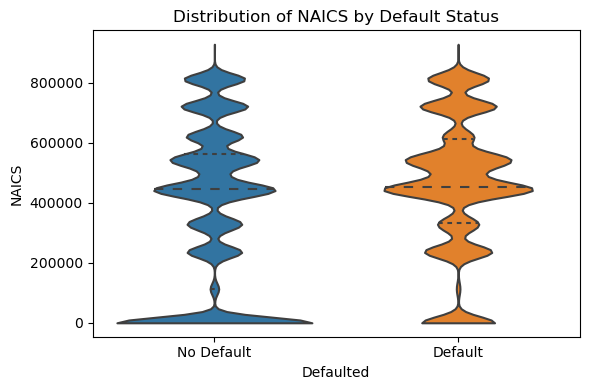

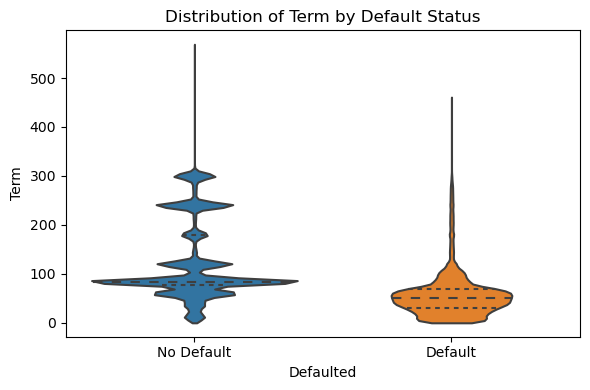

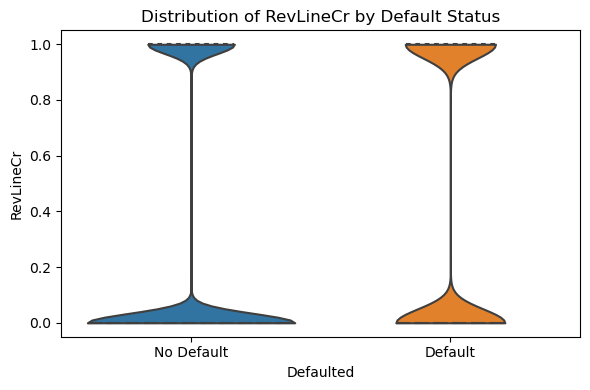

In [9]:
## NUMERIC FEATURES VS DEFAULTED: VIOLIN PLOTS ##

# Here we focus on a few numeric-like columns that are important in this dataset.
# Violin plots show the full distribution split by default status.

for col in ["NAICS", "Term", "RevLineCr"]:
    if col not in df.columns:
        continue

    plt.figure(figsize=(6, 4))
    sns.violinplot(x="Defaulted", y=col, data=df, cut=0, inner="quartile")
    plt.xticks([0, 1], ["No Default", "Default"])
    plt.title(f"Distribution of {col} by Default Status")
    plt.xlabel("Defaulted")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

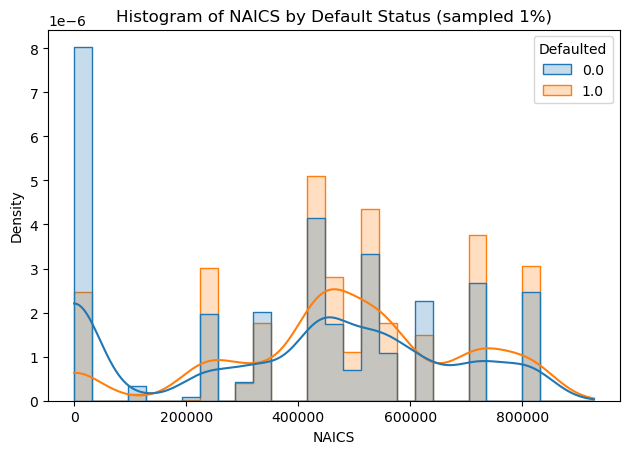

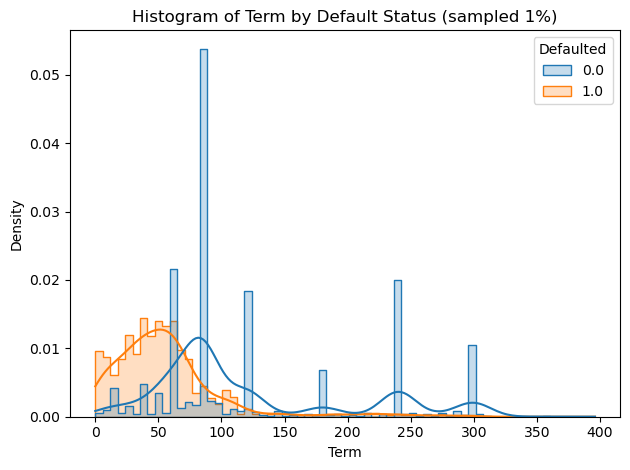

In [10]:
## NUMERIC FEATURES VS DEFAULTED: HISTROGRAMS ON A SAMPLE ##

# For heavily skewed or discrete numeric features, histograms by default status
# can be easier to interpret. We sample a small fraction of the data to keep
# plotting fast while still capturing the overall pattern.

# Sample 1% of the data for plotting

sample = df[["NAICS", "Term", "Defaulted"]].sample(frac=.01, random_state = 42)

for col in ["NAICS", "Term"]:
    temp_df = sample[[col, "Defaulted"]].replace([-np.inf, np.inf], np.nan).dropna()
    plt.figure()
    sns.histplot(data = temp_df,
                 x = col,
                 hue = "Defaulted",
                 kde = True,
                 element = "step",
                 stat = "density",
                 common_norm = False 
                )
    plt.title(f"Histogram of {col} by Default Status (sampled 1%)")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

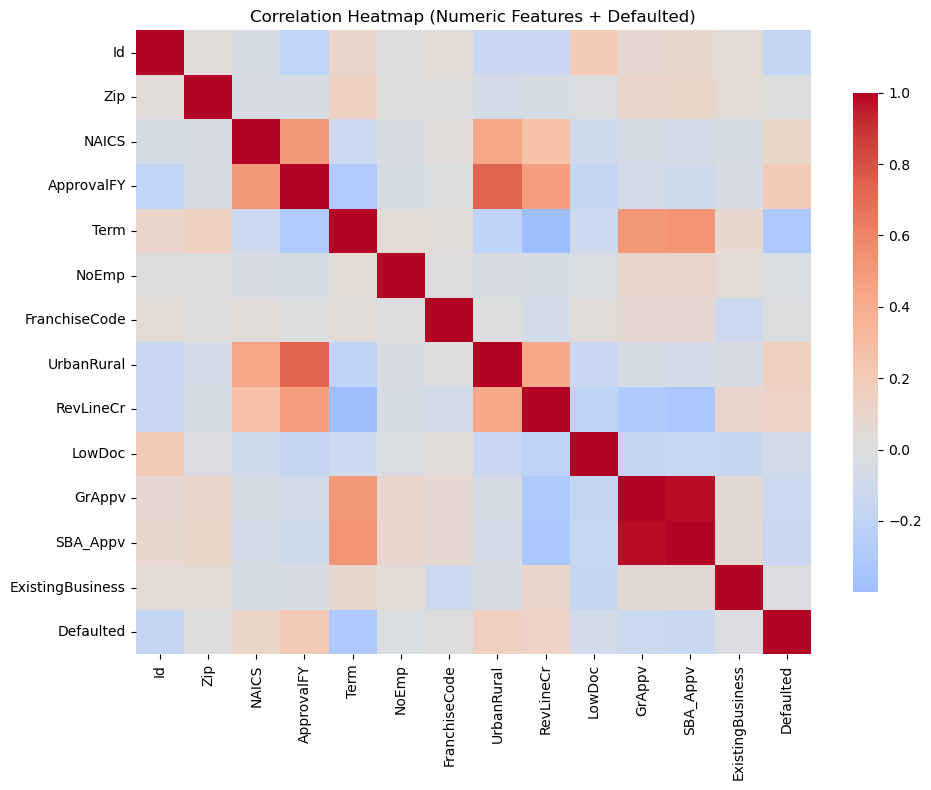

Correlation with Defaulted (sorted by corr):


ApprovalFY          0.204750
UrbanRural          0.158630
RevLineCr           0.130456
NAICS               0.105578
Zip                -0.003164
FranchiseCode      -0.015756
ExistingBusiness   -0.018979
NoEmp              -0.026140
LowDoc             -0.084013
GrAppv             -0.120746
SBA_Appv           -0.132633
Id                 -0.173784
Term               -0.314162
Name: Defaulted, dtype: float64

In [11]:
## CORRELATIONS BETWEEN NUMERIC FEATURES AND DEFAULTED ## 

# Compute correlation matrix for numeric features + target
num_features = [c for c in df.select_dtypes(include=[np.number]).columns if c != "Defaulted"]
corr = df[num_features + ["Defaulted"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=False,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap (Numeric Features + Defaulted)")
plt.tight_layout()
plt.show()

# Show the correlation of each numeric feature with Defaulted,
# sorted by absolute magnitude
target_corr = (
    corr["Defaulted"]
    .drop("Defaulted")
    .sort_values(ascending=False)
)

print("Correlation with Defaulted (sorted by corr):")
target_corr
